## Setup environment

In [1]:
import arviz as az
import bambi as bmb
import numpy as np
import pandas as pd
import pangolin as pg
import pangolin.interface as pi

## Load data

In [2]:
data = bmb.load_data("sleepstudy")

data.head()

,Reaction,Days,Subject
0,249.5600,0,308
1,258.7047,1,308
2,250.8006,2,308
3,321.4398,3,308
4,356.8519,4,308


## Specify and fit model to data using `bambi`

In [3]:
model = bmb.Model('Reaction ~ 1 + Days + (1 + Days | Subject)', data)

model

       Formula: Reaction ~ 1 + Days + (1 + Days | Subject)
        Family: gaussian
          Link: mu = identity
  Observations: 180
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 298.5079, sigma: 261.0092)
            Days ~ Normal(mu: 0.0, sigma: 48.8915)
        
        Group-level effects
            1|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 261.0092))
            Days|Subject ~ Normal(mu: 0.0, sigma: HalfNormal(sigma: 48.8915))
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 56.1721)

In [4]:
results = model.fit(draws=1000)

az.summary(results)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, Days, 1|Subject_sigma, 1|Subject_offset, Days|Subject_sigma, Days|Subject_offset]
/Users/marcoe02/src/playing_with_a_pangolin/.pixi/envs/default/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/marcoe02/src/playing_with_a_pangolin/.pixi/envs/default/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,25.784,1.524,23.034,28.734,0.025,0.026,3607.0,2932.0,1.0
Intercept,251.317,7.556,237.623,266.046,0.136,0.118,3120.0,2896.0,1.0
Days,10.492,1.672,7.223,13.496,0.037,0.033,2063.0,2204.0,1.0
1|Subject_sigma,27.113,6.620,15.165,39.015,0.142,0.132,2252.0,2384.0,1.0
Days|Subject_sigma,6.520,1.431,4.063,9.102,0.032,0.031,2126.0,2460.0,1.0
1|Subject[308],1.372,13.925,-24.540,28.005,0.204,0.208,4699.0,3203.0,1.0
1|Subject[309],-40.399,15.029,-69.291,-12.736,0.230,0.224,4303.0,3002.0,1.0
1|Subject[310],-38.907,15.068,-67.689,-11.585,0.210,0.218,5135.0,3484.0,1.0
1|Subject[330],24.753,14.149,-3.152,50.945,0.215,0.216,4341.0,2865.0,1.0
1|Subject[331],23.617,14.276,-5.242,48.740,0.212,0.221,4595.0,2739.0,1.0


array([[<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>],
       [<Axes: title={'center': 'Intercept'}>,
        <Axes: title={'center': 'Intercept'}>],
       [<Axes: title={'center': 'Days'}>,
        <Axes: title={'center': 'Days'}>],
       [<Axes: title={'center': '1|Subject_sigma'}>,
        <Axes: title={'center': '1|Subject_sigma'}>],
       [<Axes: title={'center': 'Days|Subject_sigma'}>,
        <Axes: title={'center': 'Days|Subject_sigma'}>],
       [<Axes: title={'center': '1|Subject'}>,
        <Axes: title={'center': '1|Subject'}>],
       [<Axes: title={'center': 'Days|Subject'}>,
        <Axes: title={'center': 'Days|Subject'}>]], dtype=object)

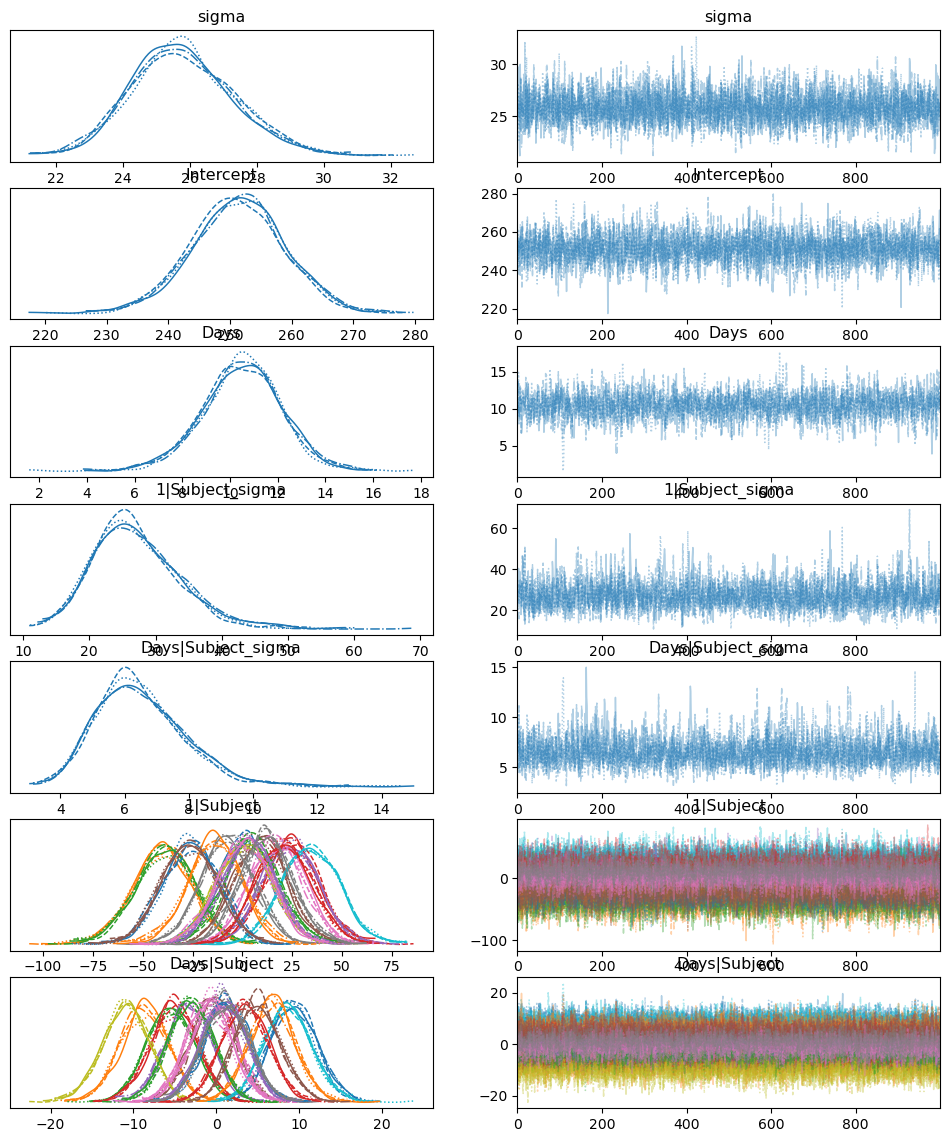

In [5]:
az.plot_trace(results)

## Specify and fit model using `pangolin`

In [74]:
α = pi.normal(100, 100)
β = pi.normal(0, 100)
σ = pi.exp(0.01)
μ = pi.vmap(lambda x: α + β * x)(data.Days)
Reaction = pi.vmap(lambda mu: pi.normal(mu, σ))(μ)

In [77]:
Reaction

InfixRV(VMap(Normal(), [0, None], 180), InfixRV(VMap(Add(), [None, 0], 180), InfixRV(Normal(), InfixRV(Constant(100)), InfixRV(Constant(100))), InfixRV(VMap(Mul(), [None, 0], 180), InfixRV(Normal(), InfixRV(Constant(0)), InfixRV(Constant(100))), InfixRV(Constant([0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9,0,1,2,3,4,5,6,7,8,9])))), InfixRV(Exp(), InfixRV(Constant(0.01))))

In [85]:
post = pg.blackjax.sample_arviz({ 'α' : α, 'β' : β, 'μ' : μ, 'σ' : σ }, Reaction, data.Reaction)

In [87]:
az.summary(post)

arviz - WARNING - Shape validation failed: input_shape: (1, 1000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
α,251.411,0.137,251.149,251.655,0.007,0.006,383.0,409.0,NaN
β,10.466,0.026,10.419,10.512,0.001,0.001,359.0,385.0,NaN
μ[0],251.411,0.137,251.149,251.655,0.007,0.006,383.0,409.0,NaN
μ[1],261.878,0.116,261.660,262.088,0.006,0.005,414.0,450.0,NaN
μ[2],272.344,0.097,272.172,272.538,0.004,0.003,478.0,566.0,NaN
...,...,...,...,...,...,...,...,...,...
μ[176],314.210,0.083,314.056,314.367,0.003,0.002,1060.0,874.0,NaN
μ[177],324.676,0.097,324.503,324.861,0.004,0.003,717.0,725.0,NaN
μ[178],335.142,0.116,334.927,335.355,0.005,0.004,583.0,538.0,NaN
μ[179],345.609,0.137,345.370,345.880,0.006,0.005,513.0,544.0,NaN
